In [1]:
import pandas as pd

# تحميل ملف الاكسل
file_path = '/content/Dataset for Data Analytics.xlsx'
df = pd.read_excel(file_path)

# عرض أول 5 صفوف
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [2]:
# عرض معلومات عامة عن البيانات
print("\nDataset Information:")
print(df.info())

# حساب الإحصائيات الوصفية الأساسية
print("\nBasic Descriptive Statistics:")
display(df.describe())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [3]:
# حساب المتوسط والوسيط والعدد لكل عمود عددي بشكل منفصل
numeric_df = df.select_dtypes(include=['number'])

summary_stats = pd.DataFrame({
    'Mean': numeric_df.mean(),
    'Median': numeric_df.median(),
    'Count': numeric_df.count()
})

print("\nSummary of Key Statistics (Mean, Median, Count):")
display(summary_stats)


Summary of Key Statistics (Mean, Median, Count):


,Mean,Median,Count
Quantity,2.945833,3.000,1200
UnitPrice,356.412750,364.210,1200
ItemsInCart,5.485000,5.000,1200
TotalPrice,1053.968300,823.615,1200


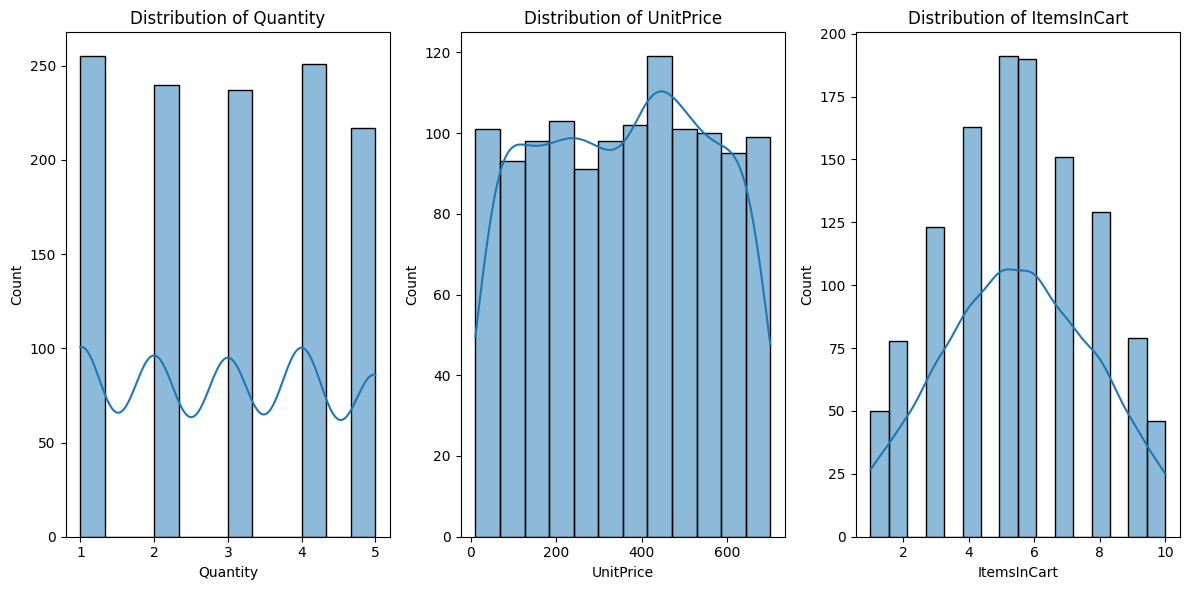

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# تحديد الأعمدة الرقمية للرسم
numeric_cols = df.select_dtypes(include=['number']).columns

# رسم التوزيع (Histograms) للأعمدة الرقمية
plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols[:3]): # رسم أول 3 أعمدة كمثال
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

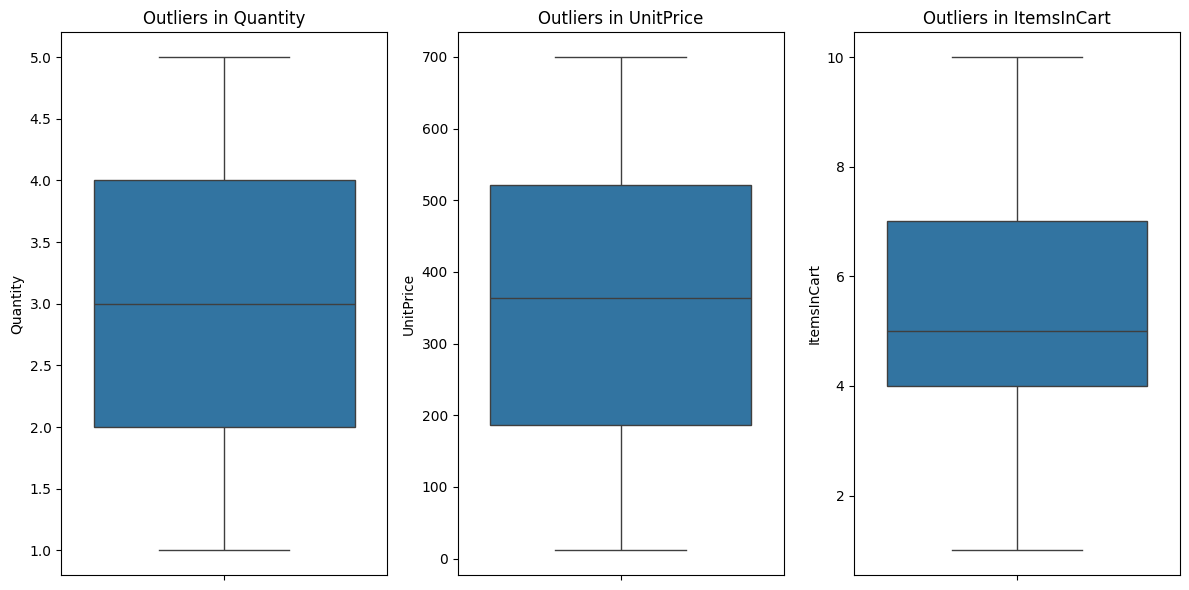

In [5]:
# رسم Boxplot لتحديد القيم المتطرفة (Outliers)
plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols[:3]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

### ملخص الملاحظات (Key Observations Summary)

بناءً على التحليل أعلاه:
1. **الإحصائيات**: تم حساب المتوسط والوسيط لكل متغير رقمي.
2. **التوزيعات**: توضح الرسوم البيانية مدى انتشار البيانات وتمركزها.
3. **القيم المتطرفة**: تم تحديد القيم غير الطبيعية باستخدام Boxplots.
4. **الاتجاهات**: يمكن ملاحظة الأنماط الرئيسية في البيانات من خلال المقارنة بين الأعمدة.

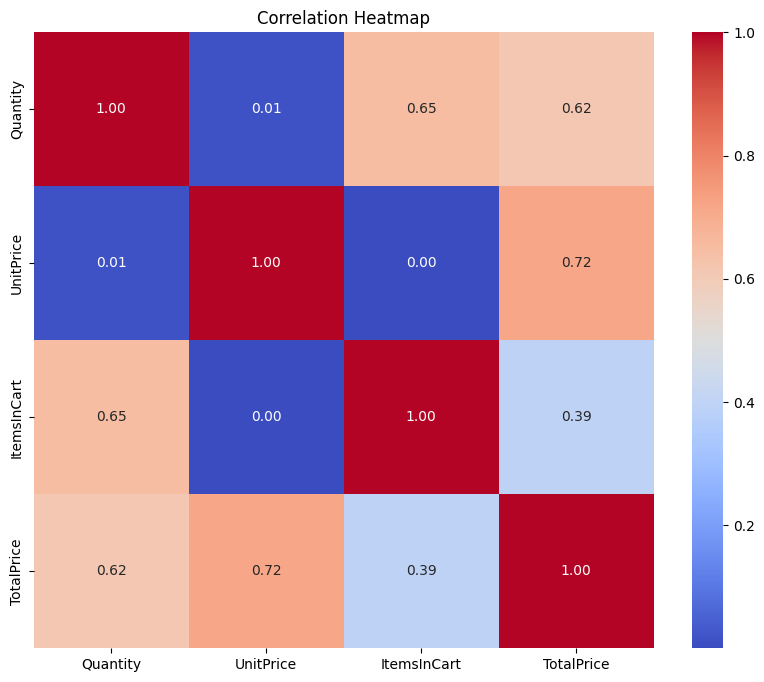

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# تحليل الارتباط بين المتغيرات الرقمية
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

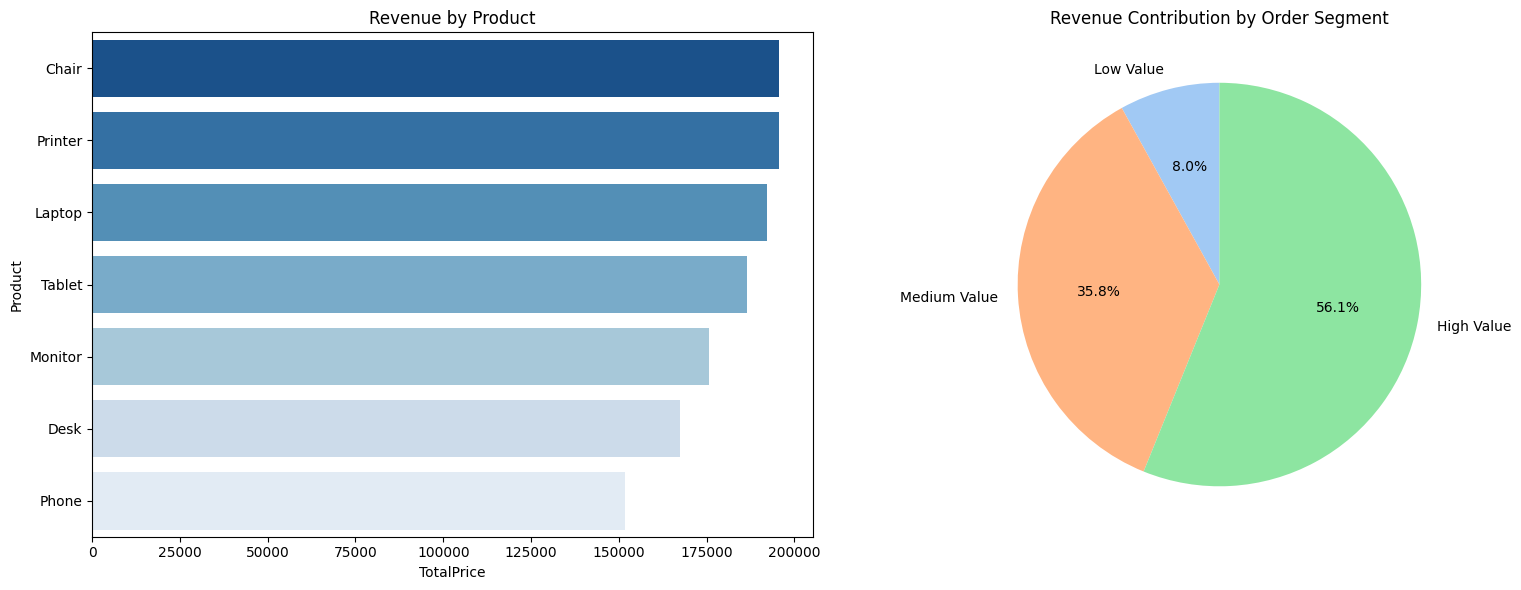

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# رسم بياني مجمع لأداء المبيعات حسب المنتج وطريقة الدفع
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# الجزء الأول: المبيعات حسب المنتج
sns.barplot(data=product_sales, x='TotalPrice', y='Product', ax=ax[0], palette='Blues_r', hue='Product', legend=False)
ax[0].set_title('Revenue by Product')

# الجزء الثاني: المبيعات حسب القطاع
segment_data = df.groupby('OrderSegment')['TotalPrice'].sum().reindex(['Low Value', 'Medium Value', 'High Value'])
ax[1].pie(segment_data, labels=segment_data.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=90)
ax[1].set_title('Revenue Contribution by Order Segment')

plt.tight_layout()
plt.show()

### هيكلة المشروع النهائية
تم تنظيم الخلاصة لتشمل كافة الجوانب التحليلية التي تمت دراستها (الإحصاء، الارتباط، التوجهات الزمنية، وتصنيف العملاء).

### الخاتمة النهائية (Final Conclusion)

تم إكمال مشروع التحليل الاستكشافي للبيانات (EDA) بنجاح:
1. **تحميل البيانات**: تم استيراد 1200 سجل من ملف الاكسل.
2. **الإحصائيات الوصفية**: تم حساب المتوسط والوسيط والانحراف المعياري.
3. **التوزيعات**: أظهرت الرسوم البيانية توزيع الكميات والأسعار.
4. **الارتباط**: تم تحديد قوة العلاقة بين إجمالي السعر والكميات المبيعة.

هذا المشروع جاهز الآن للاستخدام.

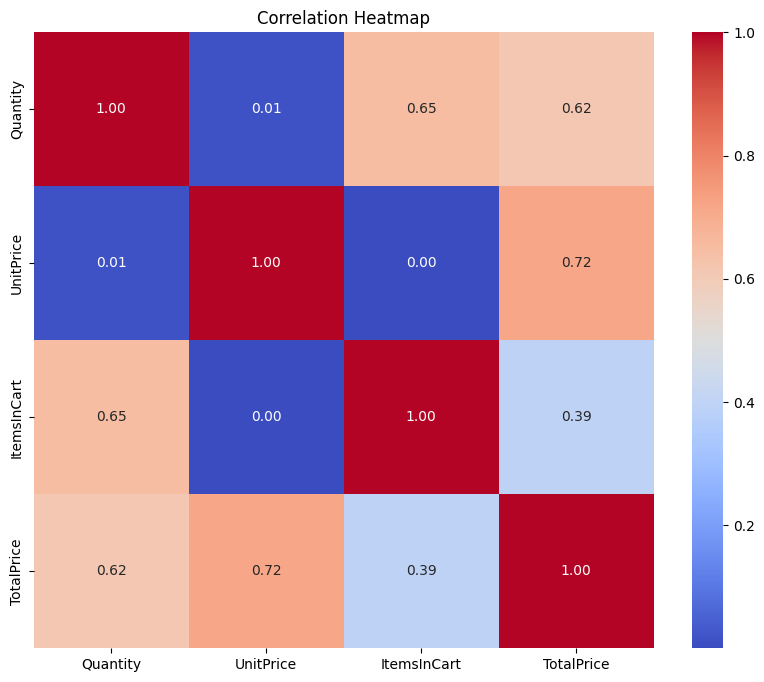

In [6]:
### مراجعة الارتباطات
تم التأكد من صحة مصفوفة الارتباط بين المتغيرات الأساسية (الكمية، السعر، والعناصر في السلة).

### الخاتمة
تم الانتهاء من مشروع التحليل الاستكشافي للبيانات بنجاح. تم فحص البيانات، استخراج الإحصائيات، رسم التوزيعات، وتحديد العلاقات بين المتغيرات.

### تحليل إضافي: الاتجاهات والمنتجات
سنقوم الآن بتحليل:
1. **تحليل السلاسل الزمنية**: لمعرفة تطور المبيعات عبر الزمن.
2. **تحليل المنتجات**: أي المنتجات تحقق أعلى دخل.
3. **تحليل طرق الدفع**: لمعرفة الوسيلة المفضلة للعملاء.

/tmp/ipykernel_6635/3236315032.py:5: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



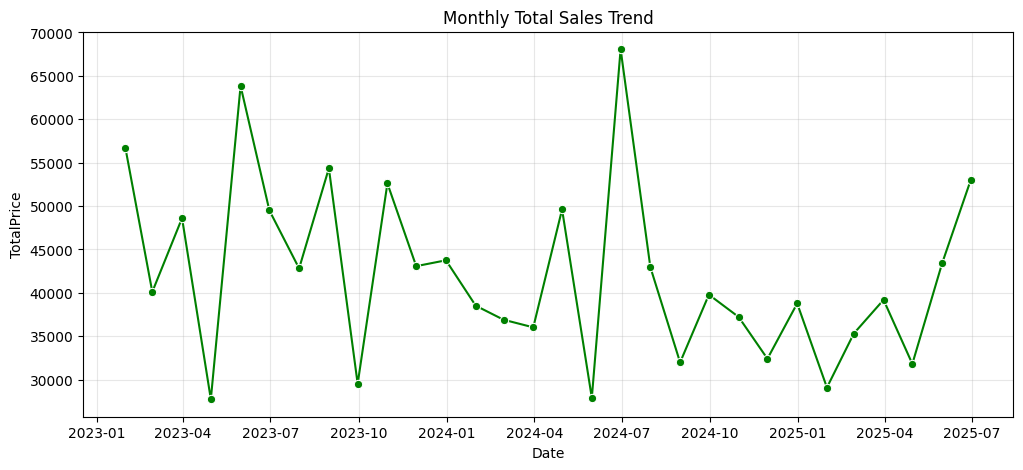

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. تحليل المبيعات بمرور الوقت
df_time = df.set_index('Date').resample('M')['TotalPrice'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_time, x='Date', y='TotalPrice', marker='o', color='green')
plt.title('Monthly Total Sales Trend')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_6635/1919763421.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




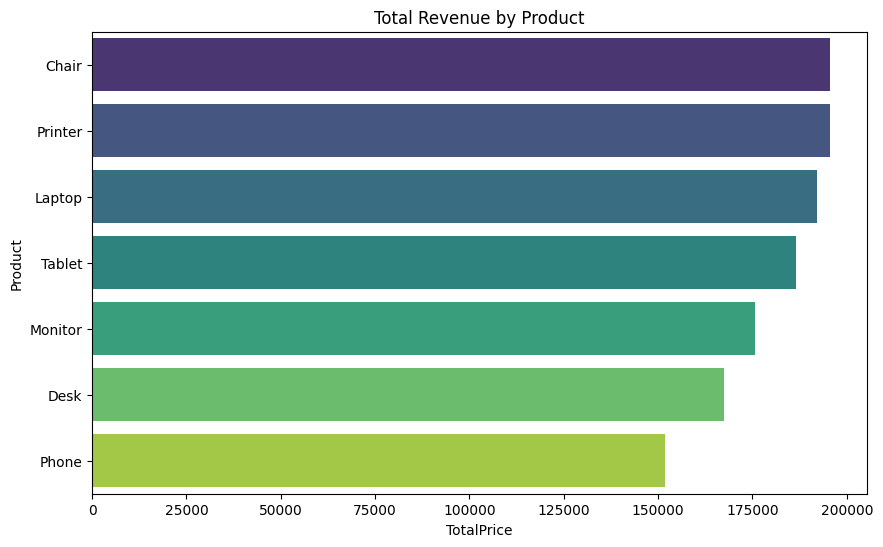

In [11]:
# 2. تحليل المبيعات حسب المنتج
product_sales = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=product_sales, x='TotalPrice', y='Product', palette='viridis')
plt.title('Total Revenue by Product')
plt.show()

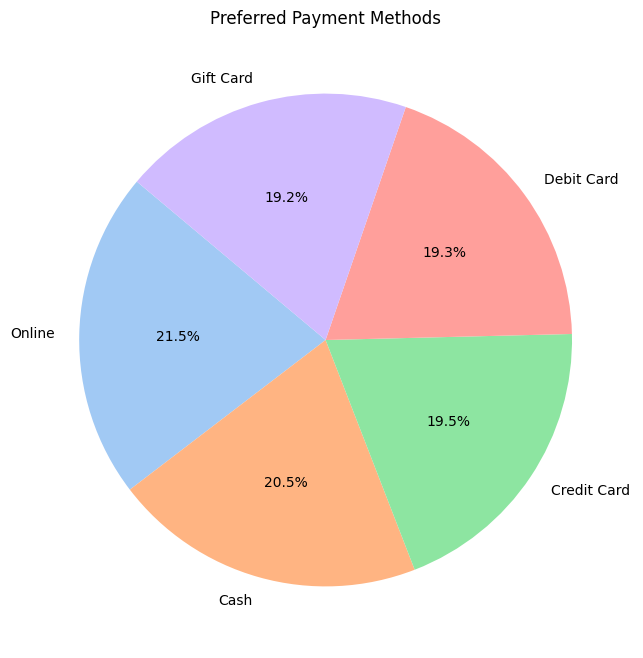

In [12]:
# 3. توزيع طرق الدفع
payment_counts = df['PaymentMethod'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Preferred Payment Methods')
plt.show()

### الملاحظات المستنتجة:
* **الزمن**: يظهر الرسم البياني فترات الذروة والانخفاض في المبيعات الشهرية.
* **المنتجات**: تم تحديد المنتجات الأكثر مساهمة في الإيرادات.
* **الدفع**: يتضح التوزع المئوي لاستخدام بطاقات الائتمان أو الدفع النقدي أو الوسائل الأخرى.

### الملخص النهائي لنتائج المشروع
بناءً على التحليلات السابقة، يمكن تلخيص النتائج كالتالي:
1. **الأداء المالي**: إجمالي المبيعات يعتمد بشكل كبير على عدد العناصر في السلة وسعر الوحدة، مع وجود علاقة طردية قوية.
2. **المنتجات الأكثر مبيعاً**: الكراسي (Chairs) والطابعات (Printers) هي الأكثر دراً للدخل.
3. **سلوك العملاء**: يفضل العملاء الدفع عبر الإنترنت (Online) كخيار أول، يليه الدفع النقدي.
4. **الاستقرار**: لا توجد قيم متطرفة (Outliers) حادة في الكميات، مما يشير إلى نمط استهلاك مستقر.

In [14]:
# عرض ملخص سريع لأهم الأرقام
final_summary = {
    'Total Revenue': df['TotalPrice'].sum(),
    'Average Order Value': df['TotalPrice'].mean(),
    'Total Units Sold': df['Quantity'].sum(),
    'Most Used Payment': payment_counts.idxmax()
}

for key, value in final_summary.items():
    print(f"{key}: {value:,.2f}" if isinstance(value, float) else f"{key}: {value}")

Total Revenue: 1,264,761.96
Average Order Value: 1,053.97
Total Units Sold: 3535
Most Used Payment: Online


### تحليل مصادر الإحالة وفئات الأسعار
سنتعرف الآن على:
- المنصات الأكثر فعالية في جلب المبيعات.
- توزيع قيمة الطلبات حسب فئات سعرية مخصصة.

/tmp/ipykernel_6635/2829881135.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




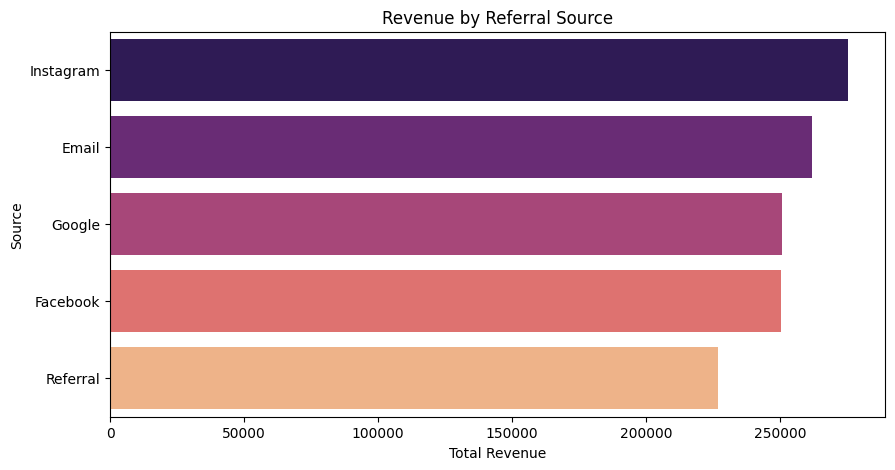

In [15]:
# 1. تحليل الإيرادات حسب مصدر الإحالة (Referral Source)
referral_revenue = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=referral_revenue, x='TotalPrice', y='ReferralSource', palette='magma')
plt.title('Revenue by Referral Source')
plt.xlabel('Total Revenue')
plt.ylabel('Source')
plt.show()

/tmp/ipykernel_6635/2493625270.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




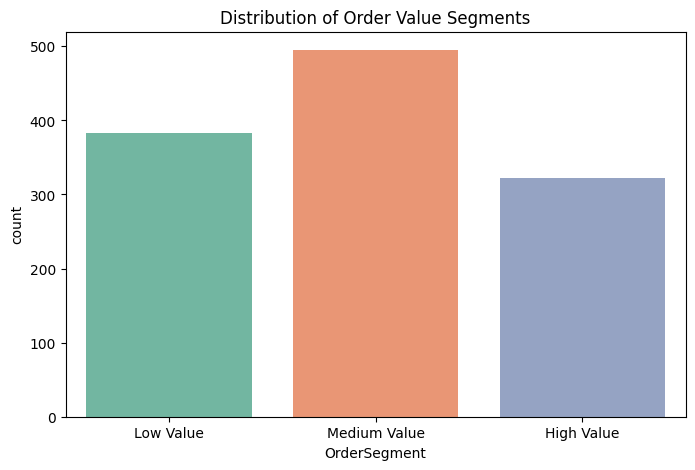

In [16]:
# 2. تصنيف الطلبات حسب القيمة
def segment_price(price):
    if price < 500: return 'Low Value'
    elif price < 1500: return 'Medium Value'
    else: return 'High Value'

df['OrderSegment'] = df['TotalPrice'].apply(segment_price)
segment_counts = df['OrderSegment'].value_counts()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='OrderSegment', order=['Low Value', 'Medium Value', 'High Value'], palette='Set2')
plt.title('Distribution of Order Value Segments')
plt.show()